<a href="https://colab.research.google.com/github/msrivarshana/machineLearningProjects/blob/main/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn  as sns

In [ ]:
df = pd.read_csv("/content/heart.csv")

In [ ]:
df.isna().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholestoral,0
fasting_blood_sugar,0
restecg,0
max_hr,0
exang,0
oldpeak,0


In [ ]:
print(df.head(10))

   age  sex  chest_pain_type  resting_bp  cholestoral  fasting_blood_sugar  \
0   63    1                3         145          233                    1   
1   37    1                2         130          250                    0   
2   41    0                1         130          204                    0   
3   56    1                1         120          236                    0   
4   57    0                0         120          354                    0   
5   57    1                0         140          192                    0   
6   56    0                1         140          294                    0   
7   44    1                1         120          263                    0   
8   52    1                2         172          199                    1   
9   57    1                2         150          168                    0   

   restecg  max_hr  exang  oldpeak  slope  num_major_vessels  thal  target  
0        0     150      0      2.3      0                  0    

In [ ]:
print(df["restecg"].unique())
print(df["restecg"].value_counts())

[2 0 1]
restecg
0    147
2    146
1      4
Name: count, dtype: int64


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

In [ ]:
df.shape

(297, 14)

In [ ]:
for i in df.columns:
  print(df[i].dtype)

int64
int64
int64
int64
int64
int64
int64
int64
int64
float64
int64
int64
int64
int64


In [ ]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["cp"].value_counts()

,count
cp,
3,142
2,83
1,49
0,23


In [ ]:
numerical_features = [
    'age',
    'trestbps',              #numerical data columns
    'chol',
    'thalach',
    'oldpeak'
]

binary_features = [
    'sex',
    'fbs',                    #binary data
    'exang'
]

categorical_features = [
    'cp',
    'restecg',
    'slope',                #multiclass data
    'thal'
]


target = 'condition'             #output column

condition
0    160
1    137
Name: count, dtype: int64


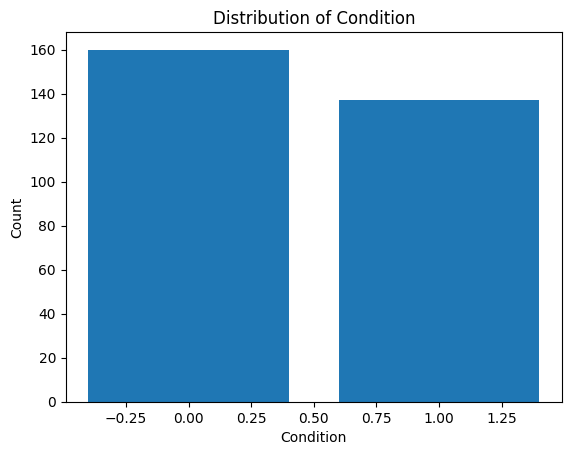

In [ ]:
condition_counts = df["condition"].value_counts()
print(condition_counts)
plt.bar(x=condition_counts.index, height=condition_counts.values)
plt.xlabel('Condition')
plt.ylabel('Count')
plt.title('Distribution of Condition')
plt.show()

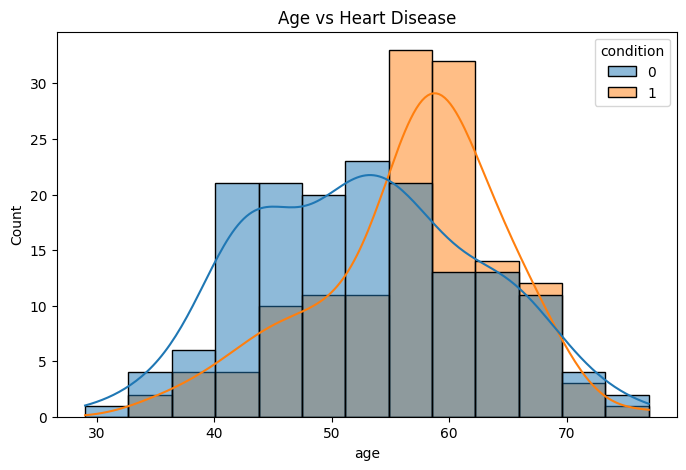

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='age', hue='condition', kde=True)

plt.title("Age vs Heart Disease")
plt.show()

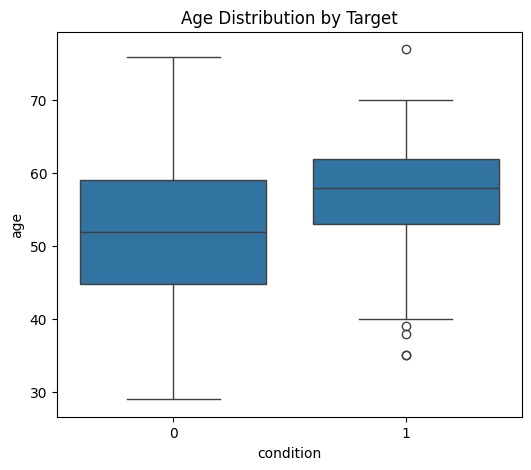

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(x='condition', y='age', data=df)

plt.title("Age Distribution by Target")
plt.show()

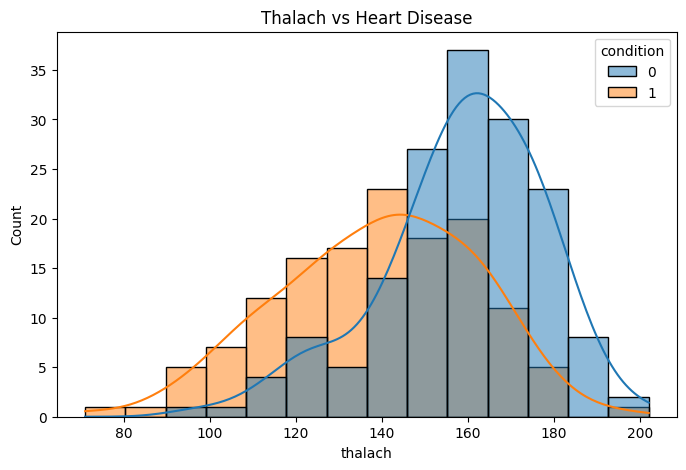

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='thalach', hue='condition', kde=True)

plt.title("Thalach vs Heart Disease")
plt.show()

In [ ]:
df["condition"].value_counts()

,count
condition,
0,160
1,137


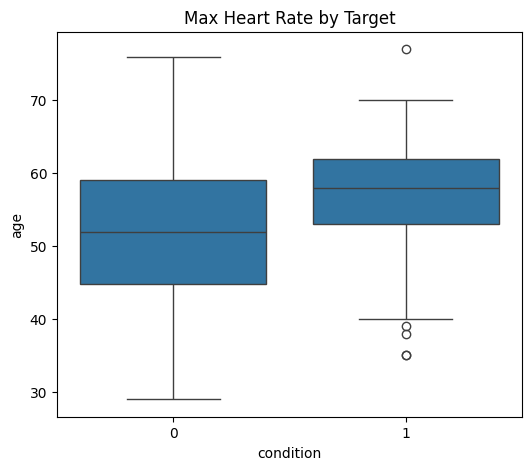

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(x='condition', y='age', data=df)

plt.title("Max Heart Rate by Target")
plt.show()

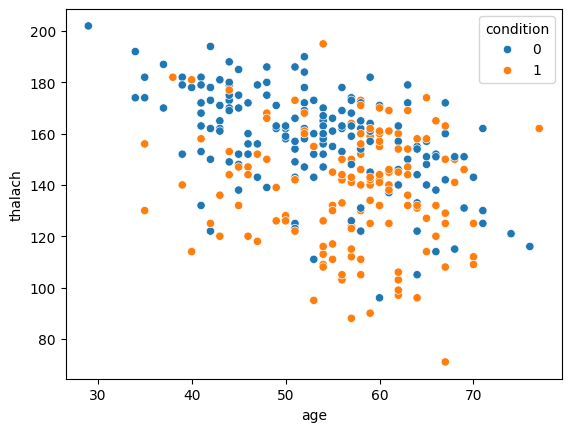

In [ ]:
sns.scatterplot(data = df , x = "age",y = "thalach",hue = "condition")
plt.show()

<Axes: xlabel='cp', ylabel='count'>

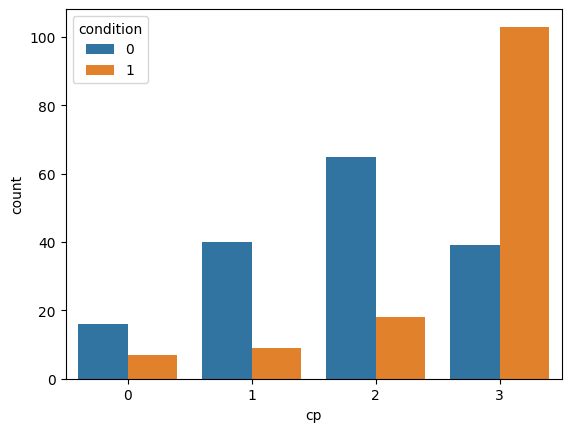

In [ ]:
sns.countplot(x='cp', hue='condition', data=df)

In [ ]:
df["cp"].unique()

array([0, 1, 2, 3])

strong features are cp,exang ,thalach

In [ ]:
X = df.drop("condition",axis=1)
y = df["condition"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd


ohe = OneHotEncoder(sparse_output= False)
encoded_cp = ohe.fit_transform(df[["cp"]])
df1 = pd.DataFrame(encoded_cp,columns = ohe.get_feature_names_out(["cp"]),index = df.index)

df = pd.concat([df.drop("cp",axis = 1),df1],axis =1)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[["restecg"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["restecg"]),
    index=df.index
)

df = pd.concat(
    [df.drop("restecg", axis=1), encoded_df],
    axis=1
)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[["slope"]])

encoded_slope = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["slope"]),
    index=df.index
)

df = pd.concat(
    [df.drop("slope", axis=1), encoded_slope],
    axis=1
)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[["thal"]])

encoded_thal = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["thal"]),
    index=df.index
)

df = pd.concat(
    [df.drop("thal", axis=1), encoded_thal],
    axis=1
)

# One-Hot Encoding for 'cp' (4 categories)
# Reason: 'cp' is a nominal categorical feature with no natural order.

In [ ]:
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,condition,...,cp_3,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2
0,69,1,160,234,1,131,0,0.1,1,0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,69,0,140,239,0,151,0,1.8,2,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,66,0,150,226,0,114,0,2.6,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,65,1,138,282,1,174,0,1.4,1,1,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,64,1,110,211,0,144,1,1.8,0,0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df.drop("condition",axis=1)
y = df["condition"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42,stratify = y)




scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)


model = LogisticRegression(max_iter=1000, solver="liblinear") # Initialize 'model' here


selector = RFE(estimator=model, n_features_to_select=16)

x_train = selector.fit_transform(X_train, y_train)

x_test = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]

print(selected_features)

# Re-define model for GridSearchCV, correcting the 'l2' NameError
# 'l2' should be a string literal '"l2"'.
model = LogisticRegression(max_iter = 1000,penalty="l2",C = 1) # Fixed penalty="l2"

param_grid = {"C" : [0.1,1,10,100],"penalty" : ["l1","l2"],"solver":["liblinear"]}
grid = GridSearchCV(estimator = model,param_grid = param_grid,cv = 5,scoring= "accuracy")
grid.fit(X_train,y_train) # Changed x_train to X_train here


print(grid.best_params_)
print(grid.best_score_)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Index(['sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca',
       'cp_0', 'cp_2', 'cp_3', 'restecg_2', 'slope_0', 'slope_1', 'thal_0',
       'thal_2'],
      dtype='object')
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
0.8275709219858157
Accuracy: 0.9166666666666666
[[32  0]
 [ 5 23]]
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60

